In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [45]:
import pandas as pd
import os

# 1. REMOVE EGX100 from this list
asset_files = {
    "final_EGX30.csv": "EGX30",
    "final_gold.csv": "Gold",
    "final_palm_hills.csv": "Palm Hills",
    "final_sodic.csv": "Sodic",
    "final_tbills.csv": "T-Bills",
    "final_tmg.csv": "TMG"
}

all_returns = []
data_path = "final_data"

# 2. Run the loop
for filename, asset_name in asset_files.items():
    file_full_path = os.path.join(data_path, filename)
    temp_df = pd.read_csv(file_full_path, index_col='date', parse_dates=True)
    asset_return = temp_df[['return']].rename(columns={'return': asset_name})
    all_returns.append(asset_return)

# 3. Merge and Bridge the Friday/Sunday gaps
master_df = pd.concat(all_returns, axis=1, sort=True)
master_df = master_df.ffill(limit=3) # Carry prices over weekends

# 4. Find the NEW Common Start (Should be 2024-06-18)
common_start = master_df.dropna().index.min()
master_df = master_df.loc[common_start:]

# 5. Final Clean
clean_master = master_df.dropna()

print(f"Overlap window: {clean_master.index.min().date()} to {clean_master.index.max().date()}")
print(f"Total trading days: {len(clean_master)}")

Overlap window: 2024-06-18 to 2026-05-01
Total trading days: 575


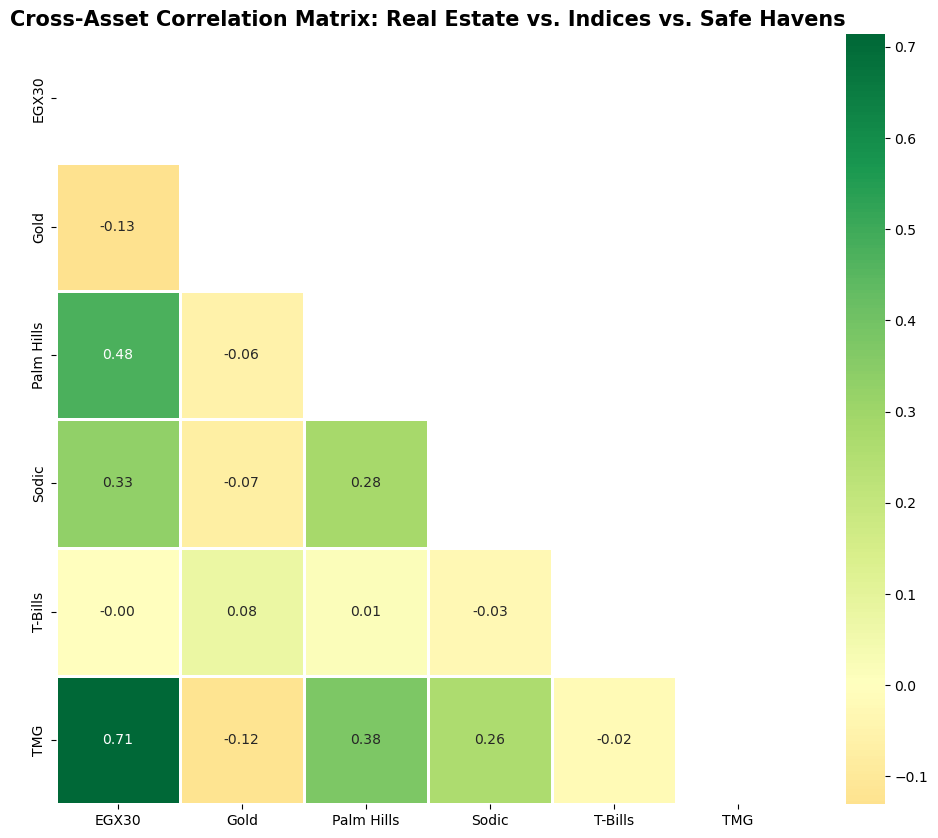

In [46]:
plt.figure(figsize=(12, 10))
corr = clean_master.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlGn', center=0, fmt=".2f", linewidths=1)
plt.title("Cross-Asset Correlation Matrix: Real Estate vs. Indices vs. Safe Havens", fontsize=15, fontweight='bold')
plt.show()

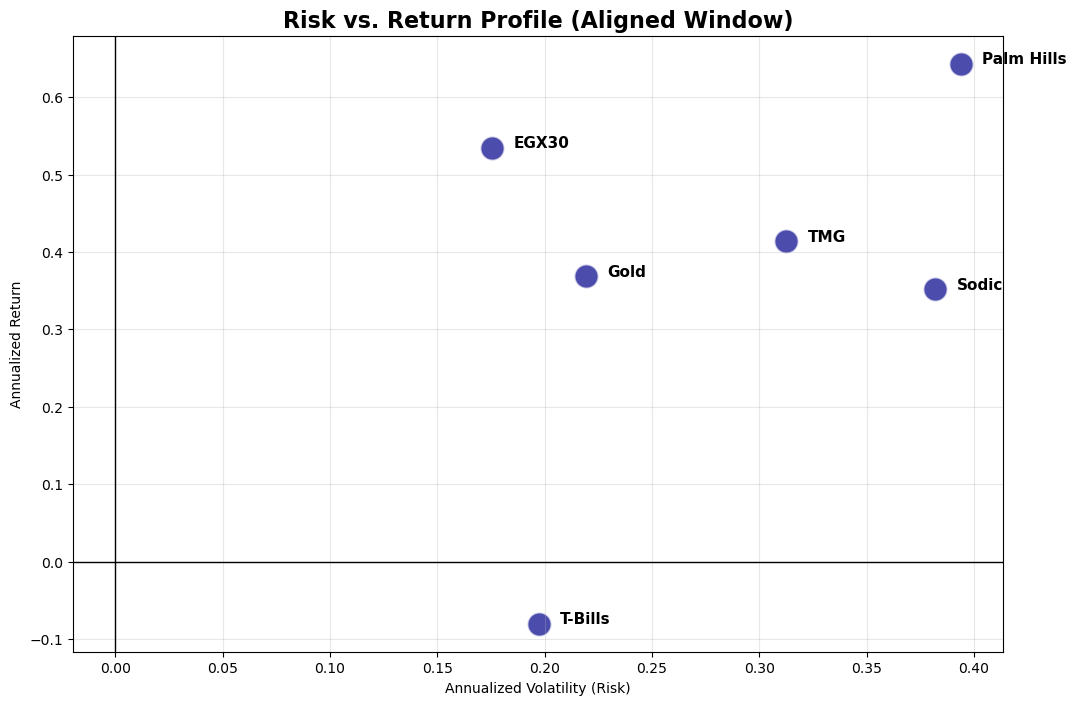

In [47]:
ann_factor = 252

# 1. Calculate stats on the CLEAN overlapping data
stats = pd.DataFrame({
    'Annualized Return': clean_master.mean() * ann_factor,
    'Annualized Volatility': clean_master.std() * np.sqrt(ann_factor)
})

plt.figure(figsize=(12, 8))
sns.scatterplot(data=stats, x='Annualized Volatility', y='Annualized Return', s=300, color='darkblue', alpha=0.7)

# 2. FIXED LOOP: Using .iloc to avoid the KeyError
for i in range(len(stats)):
    # .iloc[i] tells pandas "get the i-th row regardless of its name"
    plt.text(stats['Annualized Volatility'].iloc[i] + 0.01, 
             stats['Annualized Return'].iloc[i], 
             stats.index[i], 
             fontsize=11, 
             fontweight='bold')

plt.title("Risk vs. Return Profile (Aligned Window)", fontsize=16, fontweight='bold')
plt.xlabel("Annualized Volatility (Risk)")
plt.ylabel("Annualized Return")
plt.grid(True, alpha=0.3)
plt.axvline(0, color='black', linewidth=1)
plt.axhline(0, color='black', linewidth=1)
plt.show()

In [48]:

# 1. Configuration: Filenames and their display names
data_path = "final_data"
asset_files = {
    "final_EGX30.csv": "EGX30",
    "final_gold.csv": "Gold",
    "final_palm_hills.csv": "Palm Hills",
    "final_sodic.csv": "Sodic",
    "final_tbills.csv": "T-Bills",
    "final_tmg.csv": "TMG"
}

# 2. Loop through and collect only the 'return' column from each
all_returns = []

for filename, asset_name in asset_files.items():
    file_full_path = os.path.join(data_path, filename)
    
    # Read CSV, set date as index
    temp_df = pd.read_csv(file_full_path, index_col='date', parse_dates=True)
    
    # Extract just the return column and rename it to the asset name
    asset_return = temp_df[['return']].rename(columns={'return': asset_name})
    all_returns.append(asset_return)

# 3. Concatenate all into one Master DataFrame
# 'inner' join keeps only dates where ALL assets have data
master_df = pd.concat(all_returns, axis=1, sort=True)
master_df = master_df.sort_index()

print(f"Master dataset created with {len(master_df.columns)} assets and {len(master_df)} trading days.")
master_df.head()

Master dataset created with 6 assets and 3481 trading days.


,EGX30,Gold,Palm Hills,Sodic,T-Bills,TMG
date,,,,,,
2015-01-26,NaN,NaN,NaN,NaN,-0.071688,NaN
2015-01-27,NaN,NaN,NaN,NaN,0.000000,NaN
2015-01-28,NaN,NaN,NaN,NaN,0.000000,NaN
2015-01-29,NaN,NaN,NaN,NaN,0.000000,NaN
2015-01-30,NaN,NaN,NaN,NaN,0.000000,NaN


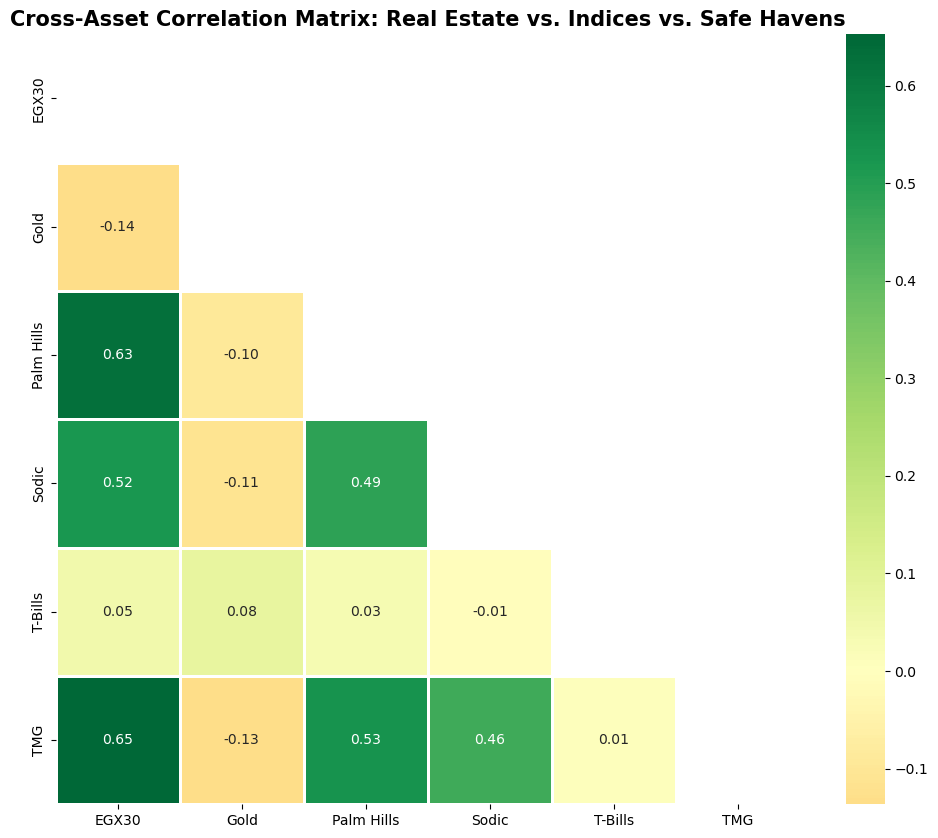

In [49]:
plt.figure(figsize=(12, 10))
corr = master_df.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlGn', center=0, fmt=".2f", linewidths=1)
plt.title("Cross-Asset Correlation Matrix: Real Estate vs. Indices vs. Safe Havens", fontsize=15, fontweight='bold')
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_14560\2909455435.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(asset_files))


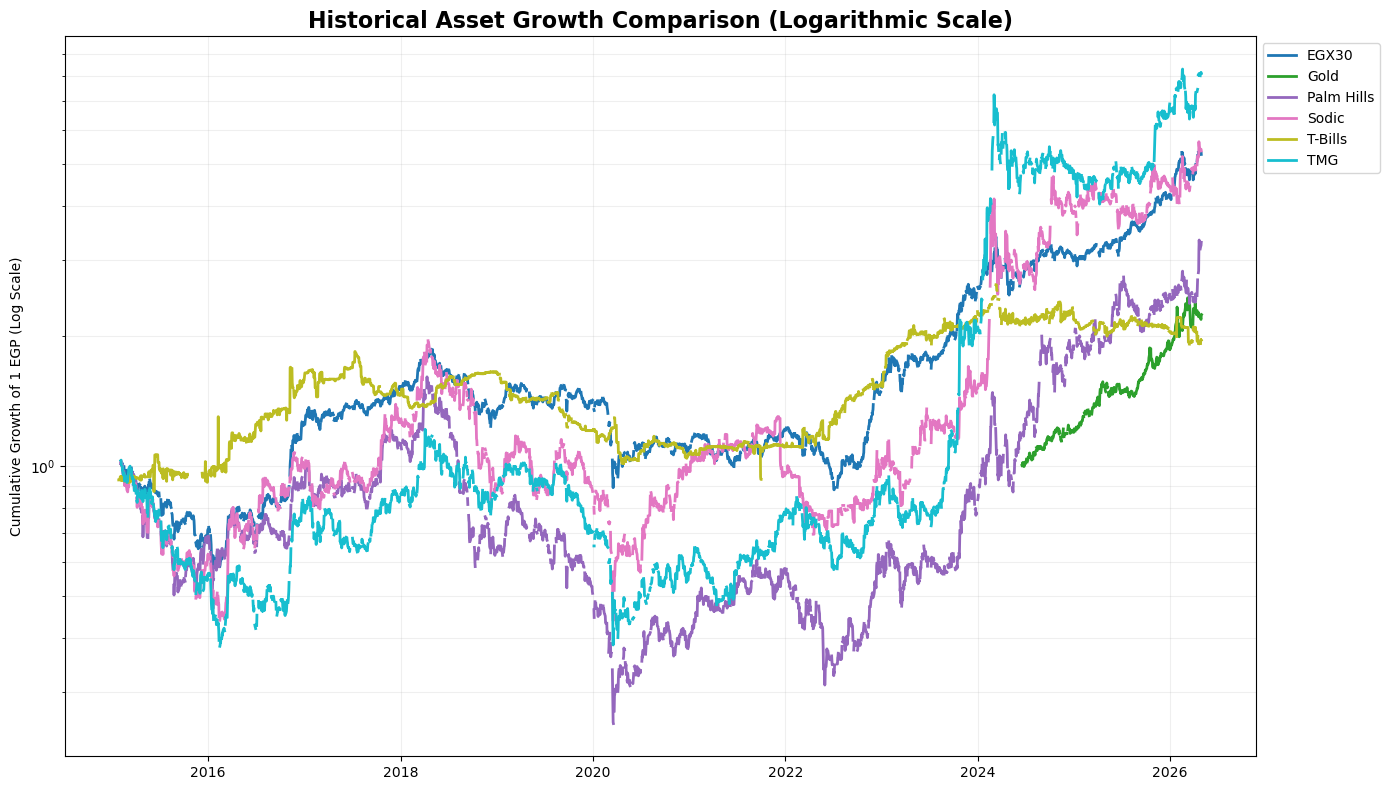

In [50]:
cum_returns = (1 + master_df).cumprod()

plt.figure(figsize=(14, 8))
# Use a color map for distinct lines
colors = plt.cm.get_cmap('tab10', len(asset_files))

for i, column in enumerate(cum_returns.columns):
    plt.plot(cum_returns[column], label=column, linewidth=2, color=colors(i))

plt.title("Historical Asset Growth Comparison (Logarithmic Scale)", fontsize=16, fontweight='bold')
plt.yscale('log') # CRITICAL for 7 assets with different scales
plt.ylabel("Cumulative Growth of 1 EGP (Log Scale)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Put legend outside for clarity
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_14560\3848696703.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(asset_files))


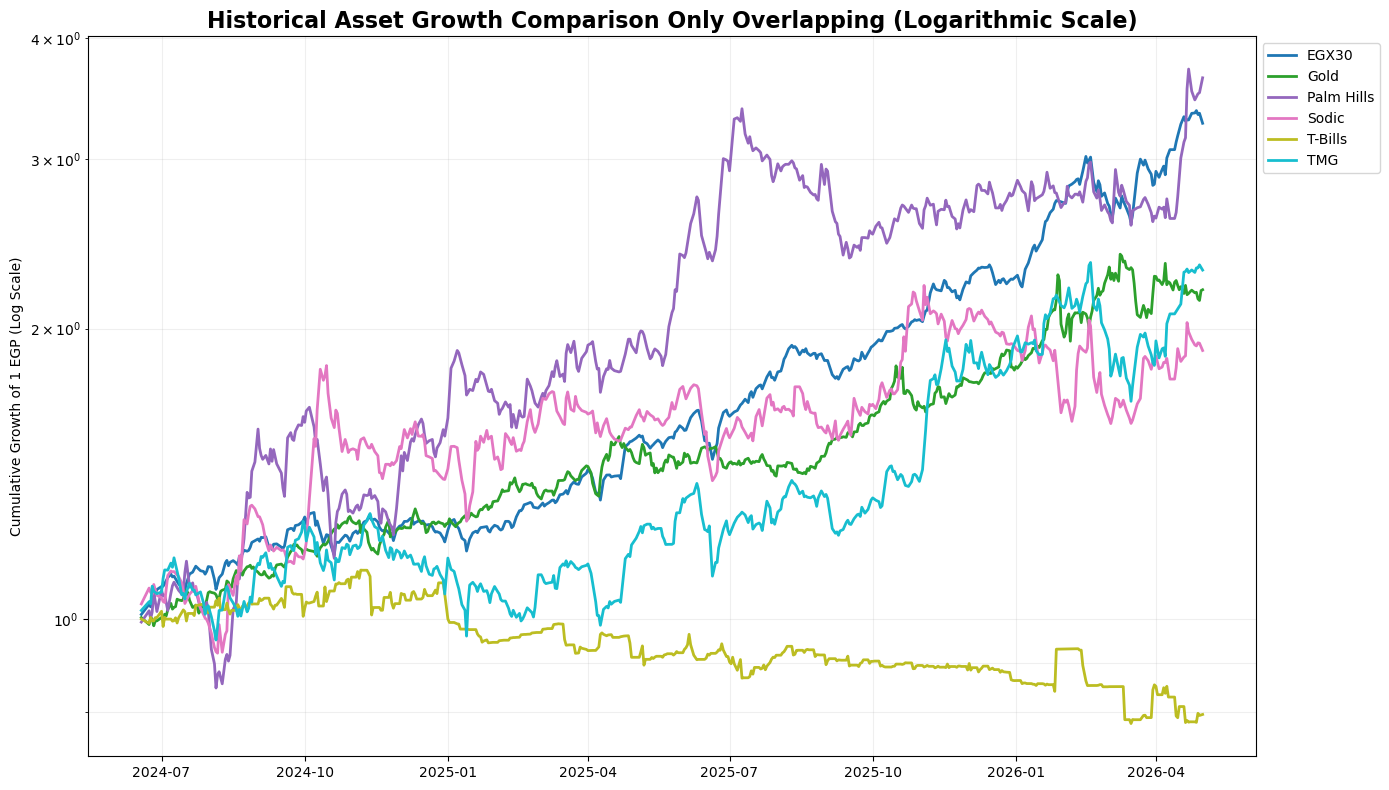

In [51]:
cum_returns = (1 + clean_master).cumprod()

plt.figure(figsize=(14, 8))
# Use a color map for distinct lines
colors = plt.cm.get_cmap('tab10', len(asset_files))

for i, column in enumerate(cum_returns.columns):
    plt.plot(cum_returns[column], label=column, linewidth=2, color=colors(i))

plt.title("Historical Asset Growth Comparison Only Overlapping (Logarithmic Scale)", fontsize=16, fontweight='bold')
plt.yscale('log') # CRITICAL for 7 assets with different scales
plt.ylabel("Cumulative Growth of 1 EGP (Log Scale)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Put legend outside for clarity
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()